# House Price Prediction using Linear Regression from Scratch

## Project Overview

This project aims to predict house prices using Multiple Linear Regression. The notebook covers the machine learning workflow, including data preprocessing, feature selection, feature engineering, model training using Gradient Descent, model evaluation and performance visualization.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
#Load dataset from csv file
original_df=pd.read_csv("train.csv")

In [3]:
# Select features for the baseline model
baseline_features=[
    'LotArea',
    'LotFrontage',
    'BedroomAbvGr', 
    'YearBuilt',  
    'HouseStyle', 
    'Neighborhood',  
    'SalePrice'
]
# Create the baseline dataset
df= original_df[baseline_features]
# Display the selected features
print(df)

      LotArea  LotFrontage  BedroomAbvGr  YearBuilt HouseStyle Neighborhood  \
0        8450         65.0             3       2003     2Story      CollgCr   
1        9600         80.0             3       1976     1Story      Veenker   
2       11250         68.0             3       2001     2Story      CollgCr   
3        9550         60.0             3       1915     2Story      Crawfor   
4       14260         84.0             4       2000     2Story      NoRidge   
...       ...          ...           ...        ...        ...          ...   
1455     7917         62.0             3       1999     2Story      Gilbert   
1456    13175         85.0             3       1978     1Story       NWAmes   
1457     9042         66.0             4       1941     2Story      Crawfor   
1458     9717         68.0             2       1950     1Story        NAmes   
1459     9937         75.0             3       1965     1Story      Edwards   

      SalePrice  
0        208500  
1        181500

In [4]:
# checking missing values
print(df.isnull().sum())

LotArea           0
LotFrontage     259
BedroomAbvGr      0
YearBuilt         0
HouseStyle        0
Neighborhood      0
SalePrice         0
dtype: int64


In [5]:
# Filling missing values. 
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].median())

In [6]:
# Verifying missing values
print(df.isnull().sum())

LotArea         0
LotFrontage     0
BedroomAbvGr    0
YearBuilt       0
HouseStyle      0
Neighborhood    0
SalePrice       0
dtype: int64


In [7]:
#Applying one hot encoding to text column
df=pd.get_dummies(df,columns=["HouseStyle", "Neighborhood"], drop_first=True, dtype=int)
print(df.head())

   LotArea  LotFrontage  BedroomAbvGr  YearBuilt  SalePrice  \
0     8450         65.0             3       2003     208500   
1     9600         80.0             3       1976     181500   
2    11250         68.0             3       2001     223500   
3     9550         60.0             3       1915     140000   
4    14260         84.0             4       2000     250000   

   HouseStyle_1.5Unf  HouseStyle_1Story  HouseStyle_2.5Fin  HouseStyle_2.5Unf  \
0                  0                  0                  0                  0   
1                  0                  1                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   HouseStyle_2Story  ...  Neighborhood_NoRidge  Neighborhood_NridgHt  \
0                  1  ...                     0              

In [8]:
# Isolate features(X) & target (y)
X=df.drop('SalePrice', axis=1)
y=df['SalePrice']

# Split data (80% for training 20% for testing)
X_train, X_test, y_train, y_test=train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=23) 

# Verify the split
print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_train.shape}")

Training feature shape: (1168, 35)
Testing feature shape: (1168, 35)


In [9]:
# Normalizaing
scaler=StandardScaler()
# Fit on training data & Transform on test
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
# Linear Regression implementation from scratch
# Compute the cost (Mean Squared Error)
def compute_cost(X, y, w, b):
    # Number of training examples
    m=X.shape[0]
    cost=0.0
    for i in range(m):
        f_wb_i=np.dot(X[i],w)+b
        cost=cost+(f_wb_i-y[i])**2
    cost=cost/(2*m)
    return cost

# Compute the gradients of the cost function
def compute_gradient(X, y, w, b):
    m,n=X.shape  #(number of examples, number of features)
    dj_dw=np.zeros((n,))
    dj_db=0.0
    for i in range(m):
        err=(np.dot(X[i],w)+b)-y[i]
        for j in range (n):
            dj_dw[j]=dj_dw[j]+err*X[i][j]
        dj_db=dj_db+err
    dj_dw=(1/m)*dj_dw
    dj_db=(1/m)*dj_db
    return dj_dw, dj_db

# Train the model using Gradient Descent
def gradient_descent(X, y, w_in, b_in, alpha, num_iter):
    w=w_in
    b=b_in
    J_history=[] # for graphing later
    for i in range(num_iter):
        
        dj_dw, dj_db=compute_gradient(X, y, w, b)
        #update weight & bias
        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        #Save current cost to history
        cost=compute_cost(X, y, w, b)
        J_history.append(cost)
    return w, b, J_history

In [11]:
n=X_train_scaled.shape[1] #feature count
#Initializing Parameters
initial_w=np.zeros((n,))
initial_b=0.0

iterations=1000
alpha=0.1

w_final, b_final, J_history=gradient_descent(X_train_scaled, np.array(y_train), initial_w, initial_b, alpha, iterations)

print(f"w_final={w_final}")
print(f"b_final={b_final}")

baseline_prediction=np.dot(X_test_scaled, w_final)+ b_final
baseline_mae=mean_absolute_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

print(f"Custom MAE: {baseline_mae:.2f}")
print(f"Custom Engine R-squared Score: {baseline_r2:.4f}")

w_final=[ 11811.79388183  12453.92879892   9576.55946426  27702.51336292
  -1653.07018852  -4764.71731628   5825.5655902    2584.73505639
   1233.36058662  -1339.61058116   -944.05244559   -943.22309127
  -5420.74493013  -3001.37340232   -870.72969716  -3258.68778387
   8274.03887944 -10248.3808582   -7184.14394812  -6010.96235685
  -5877.40479079  -6762.9471021  -10440.39001159  -1863.9860857
  -1894.54734453  18425.18291841  21363.02286944  -2556.82680772
  -2077.18027613  -9334.61354577  -3891.72840767   3968.97878889
  17614.95936764   1582.13307668   4482.87754435]
b_final=182133.37328767113
Custom MAE: 33638.92
Custom Engine R-squared Score: 0.5769


In [12]:
# Create a completely separate copy for feature engineering
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng["OverallQual"]= original_df.loc[X_train_eng.index, "OverallQual"]
X_test_eng["OverallQual"] = original_df.loc[X_test_eng.index, "OverallQual"]

X_train_eng["HouseAge"] = 2026 - X_train_eng["YearBuilt"]
X_train_eng = X_train_eng.drop(columns=["YearBuilt"])

X_test_eng["HouseAge"] = 2026 - X_test_eng["YearBuilt"]
X_test_eng = X_test_eng.drop(columns=["YearBuilt"])

# Scale the new data
X_train_scaled_new = scaler.fit_transform(X_train_eng)
X_test_scaled_new = scaler.transform(X_test_eng)

In [13]:
n_new=X_train_scaled_new.shape[1] #New feature count
initial_w_new = np.zeros((n_new, ))
initial_b_new=0.0
w_new, b_new, J_history_new=gradient_descent(X_train_scaled_new, np.array(y_train), initial_w_new, initial_b_new, alpha, iterations)

print(f"w_new={w_new}")
print(f"b_new={b_new}")

optimized_predictions = np.dot(X_test_scaled_new, w_new) + b_new

optimized_mae=mean_absolute_error(y_test, optimized_predictions)
optimized_r2 = r2_score(y_test, optimized_predictions)

print(f"optimized Custom MAE: {optimized_mae:.2f}")
print(f"optimized Custom Engine R-squared Score: {optimized_r2:.4f}")

w_new=[ 10504.36926854   6439.34012605   7509.79360057  -2342.35114243
    969.51175373   2786.45889074  -1370.81955526   1010.67231829
    -98.58538451   -214.18380054   -423.67358209  -3516.87065042
   1554.53915134   2599.32562963    -52.91380957   7389.55598794
  -2357.65210053  -2135.25622558   -740.11731117   -643.3602476
  -1759.82214749   -814.11976828  -1033.70624235   1054.17437118
  15262.42210422  14717.29063422    754.10330606    609.84063512
   -821.17030138   -486.24885638   2419.34903334  12572.45077549
   1684.06496771   3492.38504912  41147.09716887 -10858.41593404]
b_new=182133.37328767113
optimized Custom MAE: 28532.53
optimized Custom Engine R-squared Score: 0.7009


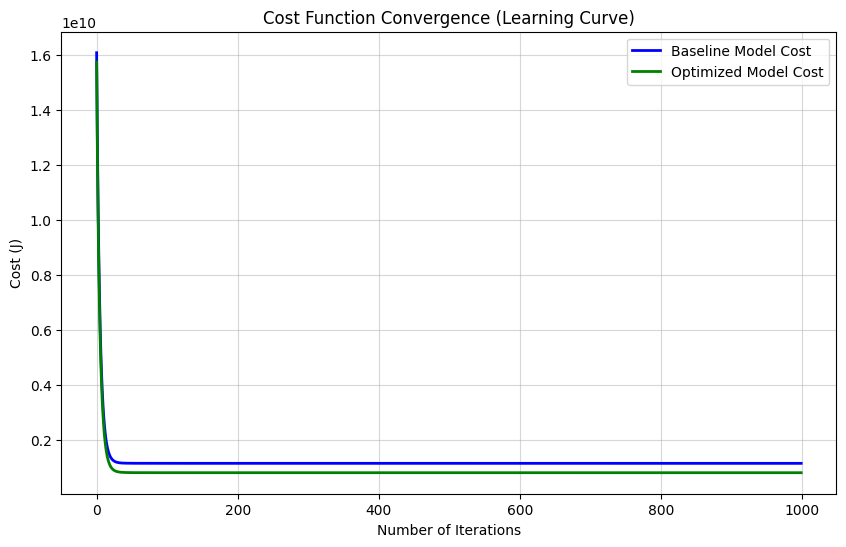

In [14]:
# Plotting the learning curves for both models
plt.figure(figsize=(10, 6))

# Plot baseline history
plt.plot(J_history, label='Baseline Model Cost', color='blue', linewidth=2)

# Plot optimized history
plt.plot(J_history_new, label='Optimized Model Cost', color='green', linewidth=2)

plt.title("Cost Function Convergence (Learning Curve)")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost (J)")
plt.legend()
plt.grid(True, alpha=0.5)

plt.show()

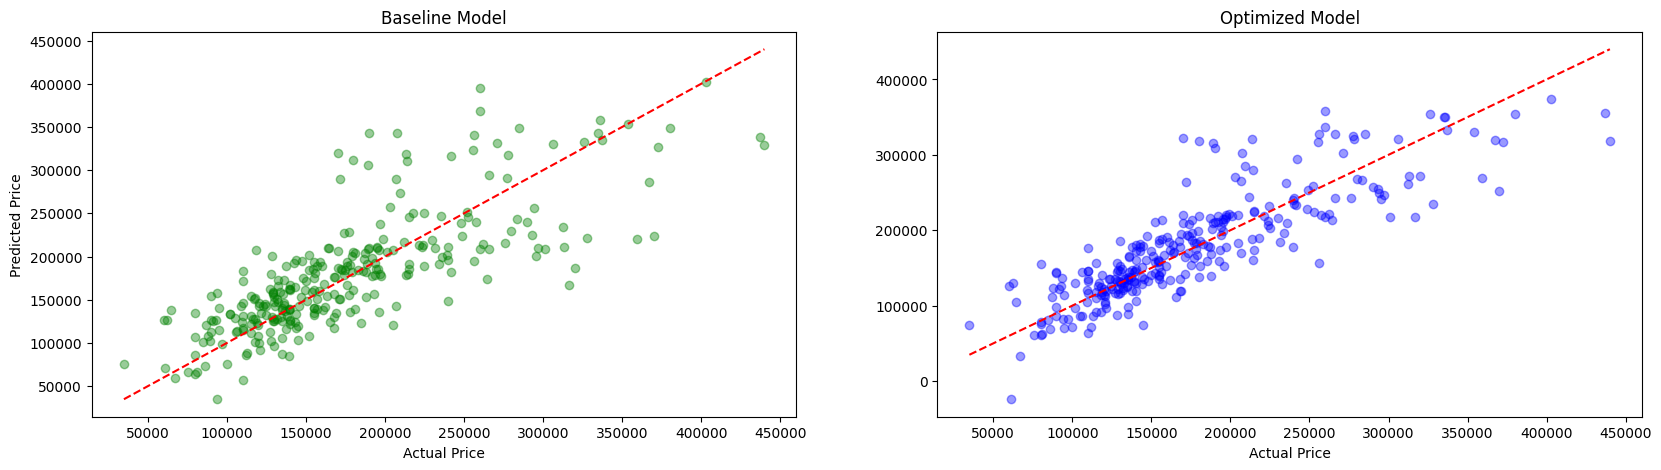

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

# Baseline Model
ax1.scatter(y_test, baseline_prediction, color="green", alpha=0.4)
ax1.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], linestyle="--", color="r")
ax1.set_title("Baseline Model")
ax1.set_xlabel("Actual Price")
ax1.set_ylabel("Predicted Price")

# Optimized Model
ax2.scatter(y_test, optimized_predictions, color="blue", alpha=0.4)
ax2.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], linestyle="--", color="r")
ax2.set_title("Optimized Model")
ax2.set_xlabel("Actual Price")

plt.show()

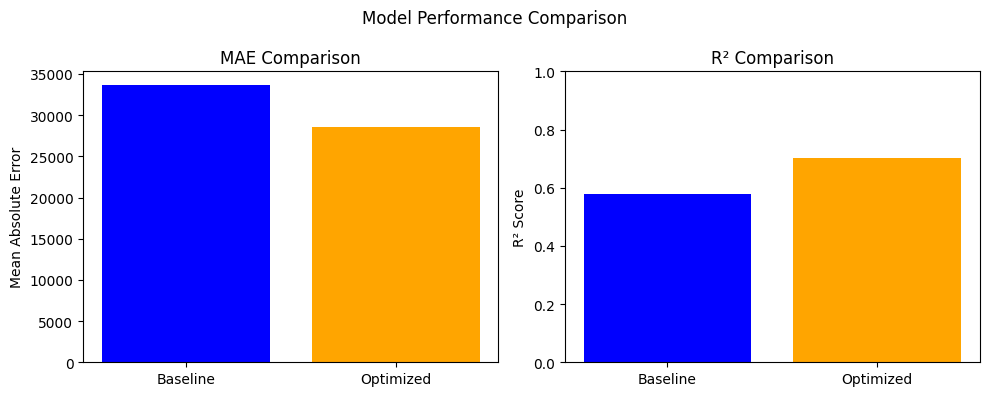

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# MAE Plot
ax[0].bar(["Baseline", "Optimized"],[baseline_mae, optimized_mae], color=["blue", "orange"])
ax[0].set_title("MAE Comparison")
ax[0].set_ylabel("Mean Absolute Error")

# R² Plot
ax[1].bar(["Baseline", "Optimized"], [baseline_r2, optimized_r2], color=["blue", "orange"])
ax[1].set_title("R² Comparison")
ax[1].set_ylabel("R² Score")
ax[1].set_ylim(0, 1)

plt.suptitle("Model Performance Comparison")
plt.tight_layout()
plt.show()

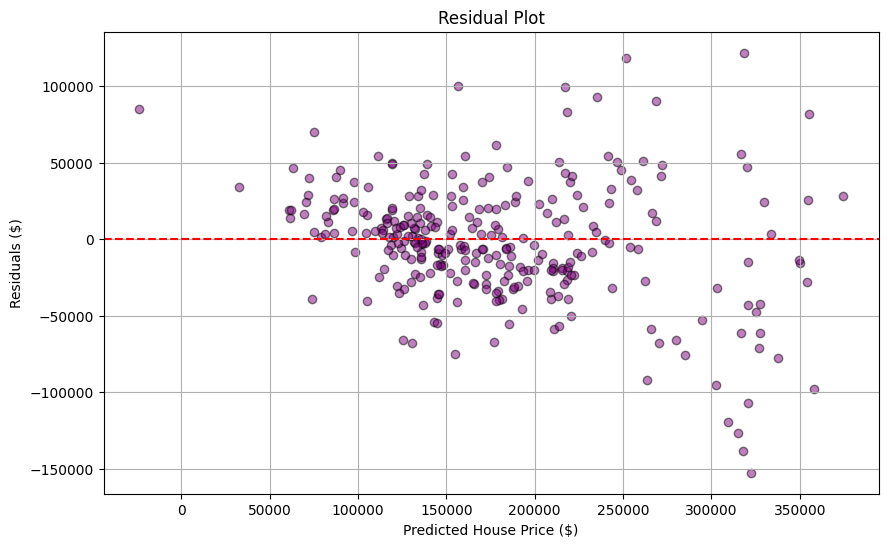

In [17]:
# Calculate residuals (Actual - Predicted)
residuals = y_test - optimized_predictions

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(optimized_predictions, residuals,color='purple', alpha=0.5, edgecolor='black')

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted House Price ($)")
plt.ylabel("Residuals ($)")
plt.grid(True)

plt.show()

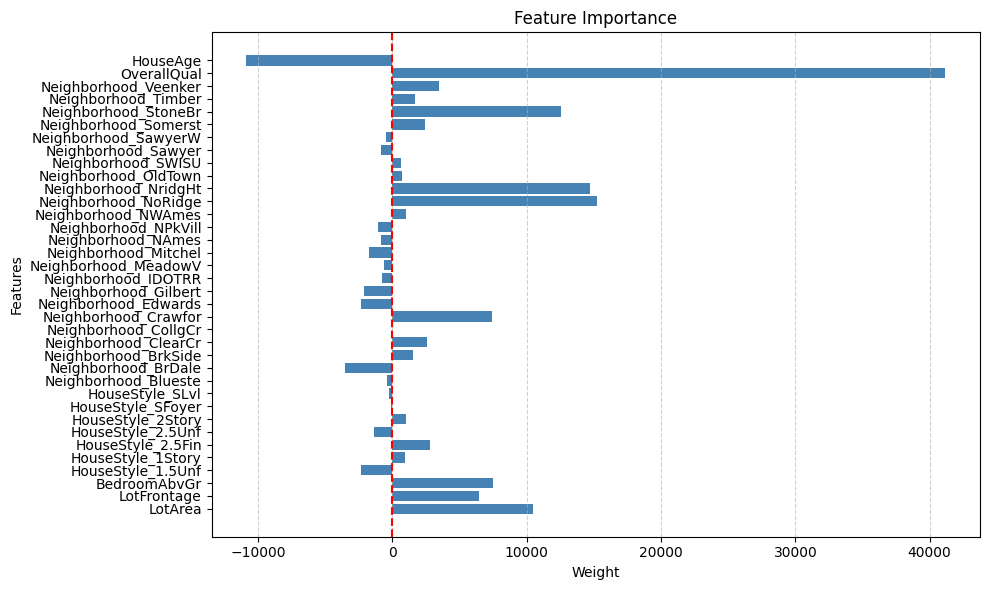

In [18]:
# Feature names
feature_names = X_train_eng.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, w_new, color='steelblue')
plt.axvline(0, color='red', linestyle='--')

plt.title("Feature Importance")
plt.xlabel("Weight")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Conclusion

This project successfully implemented Multiple Linear Regression and Gradient Descent from scratch using NumPy. By applying feature selection and feature engineering, the model's performance improved, reducing the Mean Absolute Error (MAE) from **33,638.92** to **28,532.53** and increasing the **R² Score** from **0.5769** to **0.7009**. This project highlights the importance of data preprocessing and feature engineering in building accurate machine learning models.